In [13]:
import os
import numpy as np
import h5py
from scipy import signal
from scipy.stats import pearsonr
import seaborn as sns
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import string

# Define path to data:
script_dir = os.path.dirname(os.path.abspath("Figure 1 Data Summary.ipynb"))
parent_dir = os.path.dirname(script_dir)
data_path = (parent_dir + '/dfs/')

In [20]:
# Load device, cshq, and sleep diary data file:
df_3nights = pd.read_csv(data_path+'merged_3nights.csv')
df_cshq = pd.read_csv(data_path+'df_cshq_clean.csv')

# Load subject demographics:
df_demographics = pd.read_csv(data_path+'SSP_participants.csv')

print(len(df_3nights), len(df_cshq), len(df_demographics))

1163 200 200


In [31]:
# Compute the average per subject of selected sleep measures:

df_3nights_bysub = df_3nights[['SPID', 'SOL_dreem',
                               'TST_dreem', 'TST_embrace', 'TST_withings', 'TST_diary', 
                               'WASO_dreem', 'WASO_embrace', 'WASO_withings', 'WASO_diary']].groupby('SPID').mean()

# Replace SOL_dreem values larger than 120 with Nan:
df_3nights_bysub['SOL_dreem'] = df_3nights_bysub['SOL_dreem'].apply(lambda x: np.nan if x>120 else x)

print(len(df_3nights_bysub))

136


In [27]:
# Merge demographic details and cshq into the dataframe:
df_3nights_demog = df_3nights_bysub.merge(df_demographics[['SPID', 'Parent RID', 'sex', 'asd', 
                                                           'age_months', 'age_years']], on='SPID', how='inner')

# Merge cshq data:
df_3nights_demog = df_3nights_demog.merge(df_cshq[['SPID', 'TST', 'WASO']], on='SPID', how='inner')

# Rename TST and WASO columns to TST_cshq and WASO_cshq:
df_3nights_demog = df_3nights_demog.rename(columns={'TST': 'TST_cshq', 'WASO': 'WASO_cshq'})


print(len(df_3nights_demog))

136


In [28]:
# Count number of ASD and Sibs:
asd_count = df_3nights_demog['asd'].sum()
sib_count = len(df_3nights_demog) - asd_count

# Compute the mean SOL_dreem for ASD and Sibs:
asd_SOL = df_3nights_demog[df_3nights_demog['asd']==1]['SOL_dreem'].mean()
sib_SOL = df_3nights_demog[df_3nights_demog['asd']==0]['SOL_dreem'].mean()

print(asd_count, sib_count, asd_SOL, sib_SOL)

69 67 37.32171704831143 29.856285775771077


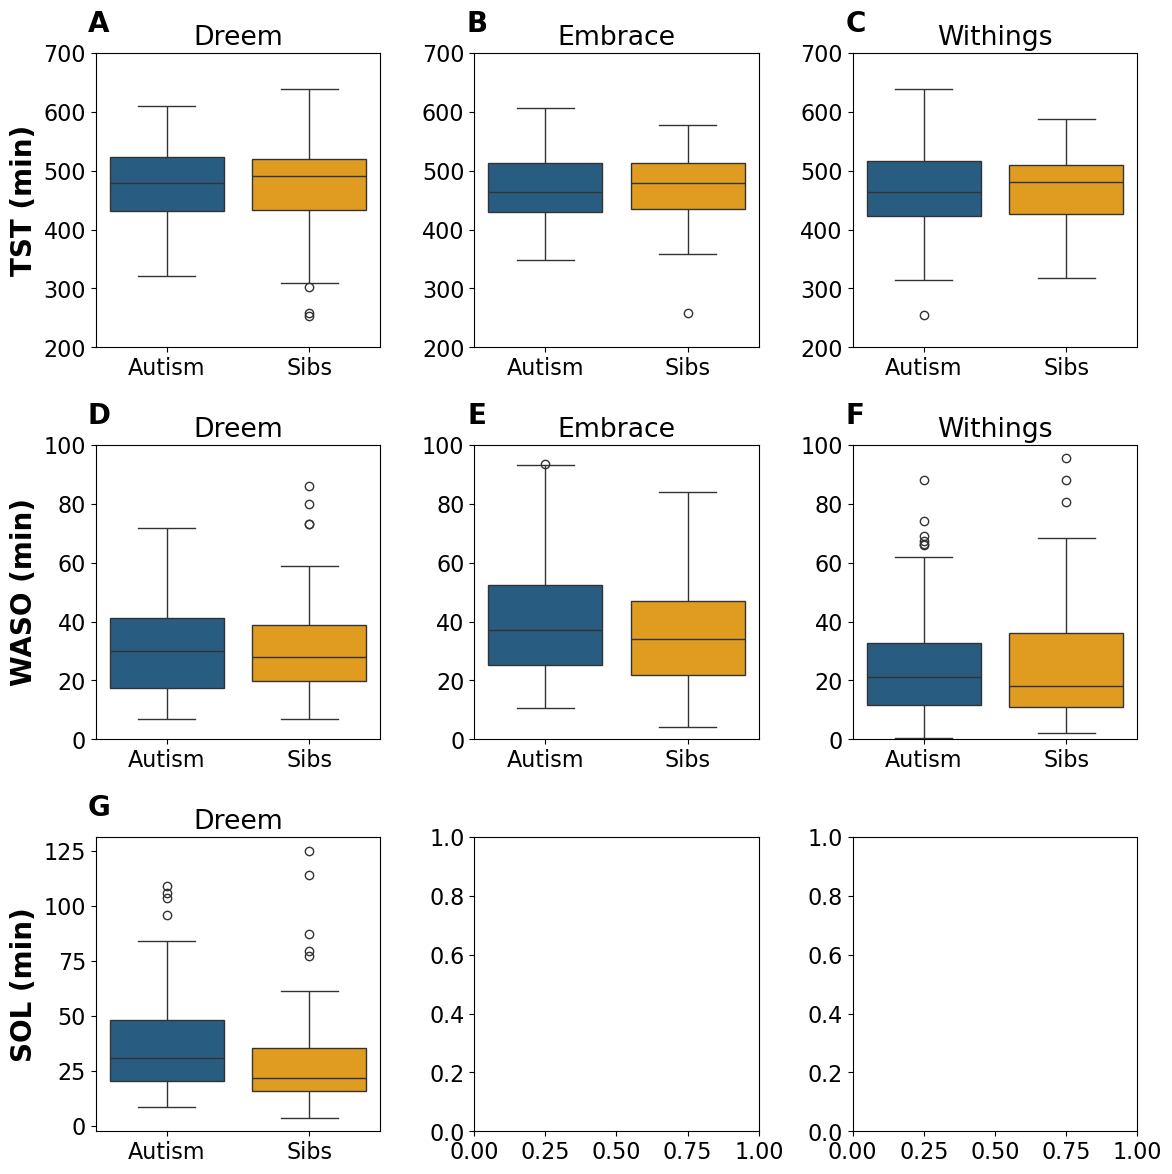

In [29]:
# List of SO FA TST and WASO columns
tst_columns = ['TST_dreem', 'TST_embrace', 'TST_withings']
waso_columns = ['WASO_dreem', 'WASO_embrace', 'WASO_withings']
sol_columns = ['SOL_dreem']

# Combine all columns to plot
columns_to_plot = tst_columns + waso_columns + sol_columns

# Organize the data by group:
df_3nights_demog['Group'] = df_3nights_demog.apply(lambda row: 'Autism' if row['asd'] else 'Sibs', axis=1)


# Order in which to plot the groups:
group_order = ['Autism', 'Sibs']

# Create a figure with 10 subplots (4 rows, 5 columns)
fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharey=False)

# Define a color palette for the groups
hue_colors = {'Autism': '#19609080', 'Sibs': '#FFA500'}

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Set global font size for the plot
plt.rcParams.update({'font.size': 16})

# Loop through the columns and create boxplots
for i, column in enumerate(columns_to_plot):
    ax = axes[i]
    sns.boxplot(data=df_3nights_demog, x='Group', y=column, ax=ax, order=group_order, hue='Group', dodge=False, palette=hue_colors)
    # Isolate the metric name from the column name:
    metric = column.split('_')[0].upper()
    if metric == 'TST':
        ax.set_ylim(200, 700)
    elif metric == 'WASO':
        ax.set_ylim(0, 100)

    
    # Isolate the metric name and device name from the column name
    metric, device = column.split('_')[0].upper(), column.split('_')[1].capitalize()

    ax.set_title(device)

    # Add capital letters in the top left corner of each panel
    panel_label = string.ascii_uppercase[i]  # Get the corresponding letter (A, B, C, etc.)
    ax.text(0.01, 1.1, panel_label, transform=ax.transAxes, fontsize=20, fontweight='bold', va='center', ha='center')

    ax.set_xlabel('')
    ax.set_ylabel('')

    # Enlarge x and y tick markers
    ax.tick_params(axis='both', which='major', labelsize=16)

# Add a title to each row:
axes[0].set_ylabel('TST (min)', fontsize=20, fontweight='bold')
axes[3].set_ylabel('WASO (min)', fontsize=20, fontweight='bold')
axes[6].set_ylabel('SOL (min)', fontsize=20, fontweight='bold')

# Adjust layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()

Run a mixed model analysis:

In [30]:
import statsmodels.formula.api as smf

# List of sleep measures to analyze
sleep_measures = ['TST_dreem', 'TST_embrace', 'TST_withings', 
                  'WASO_dreem', 'WASO_embrace', 'WASO_withings', 'SOL_dreem']

# Initialize a list to store results
all_results = []

# Add underscore to all column names with spaces:
df_3nights_demog.columns = df_3nights_demog.columns.str.replace(' ', '_')

# Preprocessing: Ensure no missing data for required variables
df_3nights_demog = df_3nights_demog.dropna(subset=sleep_measures + ['asd','sex', 'age_months', 'Parent_RID'])

# Iterate through each sleep measure
for measure in sleep_measures:
    print(f"Analyzing {measure}")
    
    # Check if the measure exists in the DataFrame
    if measure not in df_3nights_demog.columns:
        print(f"  Warning: {measure} not found in df_3nights_demog, skipping...")
        continue

    # Define the formula
    formula = f"{measure} ~ asd + sex + age_months"
    
    try:
        # Fit the mixed-effects model
        model = smf.mixedlm(formula, df_3nights_demog, groups=df_3nights_demog["Parent_RID"])
        result = model.fit()
        
        # Extract variance components
        random_effects_variance = result.cov_re.iloc[0, 0]  # Between-group variance
        residual_variance = result.scale  # Within-group (residual) variance
        
        # Calculate the intraclass correlation coefficient (ICC)
        icc = random_effects_variance / (random_effects_variance + residual_variance)
        
        # Extract fixed-effect estimates and p-values
        asd_effect = result.params.get('asd[T.True]', float('nan'))
        asd_pvalue = result.pvalues.get('asd[T.True]', float('nan'))
        sex_effect = result.params.get('sex[T.Male]', float('nan'))
        sex_pvalue = result.pvalues.get('sex[T.Male]', float('nan'))
        age_effect = result.params.get('age_months', float('nan'))
        age_pvalue = result.pvalues.get('age_months', float('nan'))
        
        # Append the results
        all_results.append({
            "Measure": measure,
            "Between-Pair Variance": random_effects_variance,
            "Within-Pair Variance": residual_variance,
            "ICC": icc,
            "ASD Effect (Beta)": asd_effect,
            "ASD Effect p-value": asd_pvalue,
            "Sex Effect (Beta)": sex_effect,
            "Sex Effect p-value": sex_pvalue,
            "Age Effect (Beta)": age_effect,
            "Age Effect p-value": age_pvalue
        })
    
    except Exception as e:
        print(f"  Error analyzing {measure}: {e}")

# Convert all results to a DataFrame for better visualization
results_df = pd.DataFrame(all_results)

# Display the results
print("\nSummary of Mixed Model Analysis:")
print(results_df)

# Save results to a CSV file (optional)
results_df.to_csv("mixed_model_results_3nights.csv", index=False)


Analyzing TST_dreem
Analyzing TST_embrace
Analyzing TST_withings
Analyzing WASO_dreem
Analyzing WASO_embrace
Analyzing WASO_withings
Analyzing SOL_dreem

Summary of Mixed Model Analysis:
         Measure  Between-Pair Variance  Within-Pair Variance           ICC  \
0      TST_dreem           2.626421e+03           1925.112928  5.770409e-01   
1    TST_embrace           2.100801e+03           1310.982338  6.157486e-01   
2   TST_withings           1.931309e+03           2038.372661  4.865148e-01   
3     WASO_dreem           1.040020e+02            185.992156  3.586349e-01   
4   WASO_embrace           8.720869e+01            383.051582  1.854477e-01   
5  WASO_withings           4.736072e-08            433.369884  1.092847e-10   
6      SOL_dreem           7.215515e+01            515.066697  1.228754e-01   

   ASD Effect (Beta)  ASD Effect p-value  Sex Effect (Beta)  \
0          10.498750            0.244078         -17.463471   
1          11.555534            0.121905         -28.1

c:\Users\Ilan\anaconda3\envs\SSP_Analysis\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Add underscores to all column names in CSHQ dataframe:
df_cshq.columns = [col.replace(" ", "_") for col in df_cshq.columns]
# Remove CSHQ rows where TST or WASO are missing:
df_cshq = df_cshq.dropna(subset=['TST', 'WASO'])

# Define sleep measures and data frames to analyze
# sleep_measures = ['TST', 'WASO', 'SO_FromMidNight', 'FA_FromMidNight']
sleep_measures = ['TST', 'WASO']
data_frames = {
    "Dreem": df_dreem_demog,
    "Embrace": df_embrace_demog,
    "Withings": df_withings_demog,
    "Diary": df_diary_demog,
    "CSHQ": df_cshq
}

# Initialize a results list to store variance components and ICCs
all_results = []

# Iterate through each data frame
for df_name, df in data_frames.items():
    print(f"Analyzing data from {df_name}...")
    
    # Analyze each sleep measure
    for measure in sleep_measures:
        print(f"  Analyzing {measure} with ASD, Sex, and Age as fixed effects...")
        
        # Check if measure exists in the current DataFrame
        if measure not in df.columns:
            print(f"  Warning: {measure} not found in {df_name}, skipping...")
            continue

        # Define the formula
        formula = f"{measure} ~ asd + sex + age_months"
        
        try:
            # Fit the mixed-effects model
            model = smf.mixedlm(formula, df, groups=df["Parent_RID"])
            result = model.fit()
            
            # Extract variance components
            random_effects_variance = result.cov_re.iloc[0, 0]  # Between-group variance
            residual_variance = result.scale  # Within-group (residual) variance
            
            # Calculate the intraclass correlation coefficient (ICC)
            icc = random_effects_variance / (random_effects_variance + residual_variance)
            
            # Extract fixed-effect estimates and p-values
            asd_effect = result.params.get('asd[T.True]', float('nan'))
            asd_pvalue = result.pvalues.get('asd[T.True]', float('nan'))
            sex_effect = result.params.get('sex[T.Male]', float('nan'))
            sex_pvalue = result.pvalues.get('sex[T.Male]', float('nan'))
            age_effect = result.params.get('age_months', float('nan'))
            age_pvalue = result.pvalues.get('age_months', float('nan'))
            
            # Append the results
            all_results.append({
                "DataFrame": df_name,
                "Measure": measure,
                "Between-Pair Variance": random_effects_variance,
                "Within-Pair Variance": residual_variance,
                "ICC": icc,
                "ASD Effect (Beta)": asd_effect,
                "ASD Effect p-value": asd_pvalue,
                "Sex Effect (Beta)": sex_effect,
                "Sex Effect p-value": sex_pvalue,
                "Age Effect (Beta)": age_effect,
                "Age Effect p-value": age_pvalue
            })
        
        except Exception as e:
            print(f"  Error analyzing {measure} in {df_name}: {e}")

# Convert all results to a DataFrame for better visualization
results_df = pd.DataFrame(all_results)

# Display the results
print(results_df)


Analyzing data from Dreem...
  Analyzing TST with ASD, Sex, and Age as fixed effects...
  Analyzing WASO with ASD, Sex, and Age as fixed effects...
Analyzing data from Embrace...
  Analyzing TST with ASD, Sex, and Age as fixed effects...
  Analyzing WASO with ASD, Sex, and Age as fixed effects...
Analyzing data from Withings...
  Analyzing TST with ASD, Sex, and Age as fixed effects...
  Analyzing WASO with ASD, Sex, and Age as fixed effects...


c:\Users\Ilan\anaconda3\envs\SSP_Analysis\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Analyzing data from Diary...
  Analyzing TST with ASD, Sex, and Age as fixed effects...
  Analyzing WASO with ASD, Sex, and Age as fixed effects...
Analyzing data from CSHQ...
  Analyzing TST with ASD, Sex, and Age as fixed effects...
  Analyzing WASO with ASD, Sex, and Age as fixed effects...
  DataFrame Measure  Between-Pair Variance  Within-Pair Variance  \
0     Dreem     TST            1364.942184           2049.195835   
1     Dreem    WASO              71.511203            110.092620   
2   Embrace     TST            1505.422380           1469.348901   
3   Embrace    WASO              64.705978            204.747505   
4  Withings     TST            1215.398905           1941.244415   
5  Withings    WASO               0.000005            295.742663   
6     Diary     TST             772.261137           2322.346633   
7     Diary    WASO               3.870404             32.732707   
8      CSHQ     TST            1585.799482           2654.584266   
9      CSHQ    WASO      